In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900_5GeV_PSF2PSF3.yaml', logging={'verbosity': 3})
gta.setup()

2025-05-13 10:41:32 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0
2025-05-13 10:41:33 INFO    GTAnalysis.setup(): Running setup.
2025-05-13 10:41:33 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-13 10:41:33 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-13 10:41:33 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-13 10:41:33 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60774.984781 from DATE-END'. [astropy.wcs.wcs]
2025-05-13 10:41:33 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-13 10:41:33 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-13 10:41:33 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-13 10:41:37 INFO    G

In [3]:
gta.config

{'logging': {'prefix': '', 'chatter': 3, 'verbosity': 3},
 'fileio': {'outdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3',
  'scratchdir': '/scratch',
  'workdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3',
  'logfile': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3/fermipy.log',
  'savefits': True,
  'workdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$'],
  'outdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$|\\.png$|\\.pdf$|\\.yaml$'],
  'usescratch': False},
 'optimizer': {'optimizer': 'MINUIT',
  'tol': 0.001,
  'max_iter': 100,
  'init_lambda': 0.0001,
  'retries': 3,
  'min_fit_quality': 2,
  'verbosity': 0},
 'binning': {'projtype': 'WCS',
  'proj': 'AIT',
  'coordsys': 'GAL',
  'npix': None,
  'roiwidth': 15.0,
  'binsz': 0.05,
  'binsperdec': 8.0,
  'enumbins': None,
  'hpx_ordering_scheme': 'RING',
  'hpx_order': 10,
  

In [3]:
gta.print_roi()

2025-05-01 12:43:06 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1908.6+0915e  RadialDisk     PowerLaw          0.000       nan       112.0
4FGL J1910.2+0904c  PointSource    PowerLaw          0.430       nan       102.0
4FGL J1911.0+0905   PointSource    LogParabola       0.619       nan       672.5
4FGL J1911.8+0903c  PointSource    PowerLaw          0.808       nan        39.3
4FGL J1912.0+0927   PointSource    LogParabola       0.869       nan        24.1
4FGL J1908.7+0812   PointSource    LogParabola       1.056       nan        24.4
4FGL J1913.3+0905   PointSource    PLSuperExpCuto    1.183       nan        54.2
4FGL J1912.7+0957   PointSource    LogParabola       1.226       nan        29.3
4FGL J1911.7+1014c  PointSource    LogParabola       1.241       nan        12.7
4FGL J1913.3+1019   PointSource    PowerLaw          1.5

2025-05-01 12:43:08 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3/initial_00.xml...


2025-05-01 12:43:08 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3/initial.fits...
2025-05-01 12:43:11 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-01 12:43:12 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3/initial.npy...


<Figure size 2000x2000 with 0 Axes>

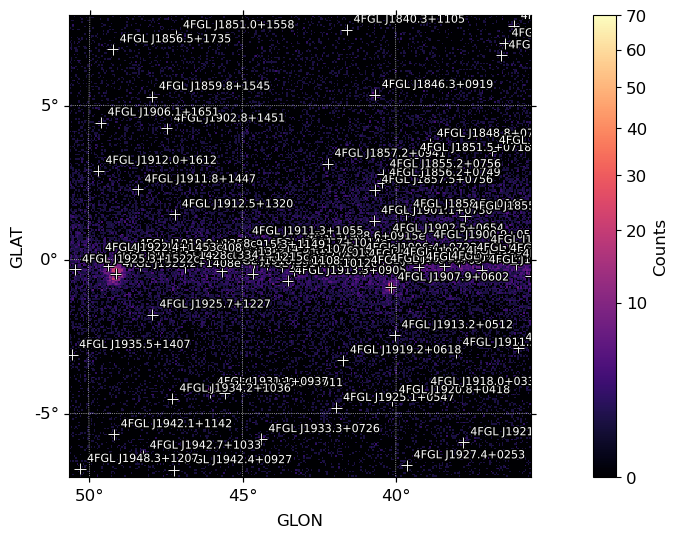

In [4]:
plt.figure(figsize=(20, 20))
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [5]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)

2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.8+0903c    : ['Prefactor', 'Index']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.7+0812     : ['norm', 'alpha', 'beta']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1913.3+0905     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-05-01 12:43:26 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.7+0957     : ['norm'

In [6]:
gta.fit()

2025-05-01 12:43:30 INFO    GTAnalysis.fit(): Starting fit.


Drm_Cache::update Measured counts < 0 4FGL J1914.7+1012c 15 -2.65399e-14 1.11361e-13
4.10998 1.37734 0.400678 0.101085 0.0220983 0.00424532 0.000729226 0.000108302 1.37085e-05 1.4879e-06 1.38366e-07 1.10642e-08 7.64125e-10 4.61433e-11 2.43367e-12 1.11361e-13 


2025-05-01 12:44:02 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-01 12:44:02 INFO    GTAnalysis.fit(): LogLike:  -141765.025 DeltaLogLike:      248.057 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 248.05662040383322,
 'edm': 4.580137450034688e-07,
 'loglike': -141765.024695684,
 'covariance': array([[ 1.40113061e-03,  1.24579413e-06,  5.39328347e-07, ...,
         -1.90480731e-10,  6.50121605e-11, -1.54398989e-14],
        [ 1.24579413e-06,  1.13945633e-04,  7.98513110e-09, ...,
          3.37703375e-11, -1.15388502e-11,  2.73986638e-15],
        [ 5.39328347e-07,  7.98513110e-09,  4.58474500e-05, ...,
          1.64705212e-11, -5.64371874e-12,  1.34189749e-15],
        ...,
        [-1.90480731e-10,  3.37703375e-11,  1.64705212e-11, ...,
          4.76906405e-08,  3.51266568e-11, -6.30945714e-15],
        [ 6.50121605e-11, -1.15388502e-11, -5.64371874e-12, ...,
          3.51266568e-11,  8.16841721e-09,  2.91316334e-15],
        [-1.54398989e-14,  2.73986638e-15,  1.34189749e-15, ...,
         -6.30945714e-15,  2.91316334e-15,  6.69257860e-16]]),
 'correlation': array([[ 1.00000000e+00,  3.11787089e-03,  

In [7]:
gta.print_roi()

2025-05-01 12:44:53 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1908.6+0915e  RadialDisk     PowerLaw          0.000     12.67        86.5
4FGL J1910.2+0904c  PointSource    PowerLaw          0.430     61.97        79.7
4FGL J1911.0+0905   PointSource    LogParabola       0.619   2001.45       660.8
4FGL J1911.8+0903c  PointSource    PowerLaw          0.808      7.36        30.7
4FGL J1912.0+0927   PointSource    LogParabola       0.869      4.94        17.5
4FGL J1908.7+0812   PointSource    LogParabola       1.056      8.63        24.9
4FGL J1913.3+0905   PointSource    PLSuperExpCuto    1.183     38.40        48.8
4FGL J1912.7+0957   PointSource    LogParabola       1.226     10.34        24.2
4FGL J1911.7+1014c  PointSource    LogParabola       1.241     12.59        19.6
4FGL J1913.3+1019   PointSource    PowerLaw          1.5

In [8]:
gta.print_model()

2025-05-01 12:45:06 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   0.759  6.79e-06   1.96     12.67        86.5    *
4FGL J1910.2+0904c     0.430   0.339  3.33e-06   2.55     61.97        79.7    *
4FGL J1911.0+0905      0.619   0.714  2.72e-05   2.20   2001.45       660.8    *
4FGL J1911.8+0903c     0.808   0.226   9.9e-07   2.97      7.36        30.7    *
4FGL J1912.0+0927      0.869   1.078  4.01e-07   4.84      4.94        17.5    *
4FGL J1908.7+0812      1.056   0.691  6.25e-07   2.65      8.63        24.9    *
4FGL J1913.3+0905      1.183   2.794  1.11e-06   4.13     38.40        48.8    *
4FGL J1912.7+0957      1.226   0.032  5.87e-07  -0.28     10.34        24.2    *
4FGL J1911.7+1014c     1.241   2.214  1.44e-06   4.52     12.59        19.6    *
4FGL J1913.3+1019      1.586   0.260  2.26e-06   2.48 

In [9]:
import numpy as np

# 1) Get your ROI center in Galactic coordinates
glon0, glat0 = gta.config['selection']['glon'], gta.config['selection']['glat']

# 2) Compute the two offsets (0.2° at 45°: upper‐right and lower‐left)
d = 0.2/np.sqrt(2)
pos = [
    (glon0 - d, glat0 + d),   # upper right
    (glon0 + d, glat0 - d)    # lower left
]

pos

gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[2.0],free=True)

# 3) (Optional) remove the original big disk
gta.delete_source('4FGL J1908.6+0915e')
gta.delete_source('disk1')
gta.delete_source('disk2')
# 4) Add your two small disks
for i, (gl, gb) in enumerate(pos, 1):
    gta.add_source(
        f'disk{i}',
        {
          'glon':         gl,
          'glat':         gb,
          'SpatialModel': 'RadialDisk',
          'Radius':       dict(value=0.2, scale=1.0, min=0.05, max=1.0),
          'SpectrumType': 'PowerLaw',
        },
        free=True,             # free all parameters of disk{i}
        init_source=True,      # do a quick local fit for each disk
        save_source_maps=True  # store their srcmaps for later
    )

2025-05-01 12:45:56 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1908.6+0915e
2025-05-01 12:45:56 ERROR   GTAnalysis.delete_source(): No source with name: disk1
2025-05-01 12:45:56 ERROR   GTAnalysis.delete_source(): No source with name: disk2
2025-05-01 12:45:56 INFO    GTAnalysis.add_source(): Adding source disk1
2025-05-01 12:46:02 INFO    GTAnalysis.add_source(): Adding source disk2


In [11]:
gta.fit()

2025-05-01 12:46:19 INFO    GTAnalysis.fit(): Starting fit.
2025-05-01 12:46:48 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-01 12:46:48 INFO    GTAnalysis.fit(): LogLike:  -141762.070 DeltaLogLike:        7.631 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 7.630579704826232,
 'edm': 1.2703958659594249e-05,
 'loglike': -141762.07008822844,
 'covariance': array([[ 5.35091044e-03,  8.64802245e-06,  3.65771837e-06, ...,
         -5.58593177e-09,  1.89720468e-09, -7.65056466e-11],
        [ 8.64802245e-06,  7.34531980e-04,  3.28841682e-07, ...,
          1.38133189e-09, -4.69270384e-10,  1.87430079e-11],
        [ 3.65771837e-06,  3.28841682e-07,  3.01584844e-04, ...,
          7.02145277e-10, -2.39359520e-10,  9.58193947e-12],
        ...,
        [-5.58593177e-09,  1.38133189e-09,  7.02145277e-10, ...,
          3.13041917e-07,  1.50963011e-09, -4.45513360e-11],
        [ 1.89720468e-09, -4.69270384e-10, -2.39359520e-10, ...,
          1.50963011e-09,  5.36760244e-08,  2.05307928e-11],
        [-7.65056466e-11,  1.87430079e-11,  9.58193947e-12, ...,
         -4.45513360e-11,  2.05307928e-11,  1.19740350e-10]]),
 'correlation': array([[ 1.00000000e+00,  4.36212005e-03,

In [14]:
gta.print_model()

2025-05-01 13:03:44 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
disk1                  0.200   0.389  1.79e-06   2.00      5.94        24.6    *
disk2                  0.200   0.542   2.5e-06   2.00     11.03        34.1    *
4FGL J1910.2+0904c     0.430   0.331  3.61e-06   2.46     68.73        80.2    *
4FGL J1911.0+0905      0.619   0.722  2.75e-05   2.22   2041.23       664.8    *
4FGL J1911.8+0903c     0.808   0.225  9.84e-07   2.96      7.24        30.4    *
4FGL J1912.0+0927      0.869   1.083  4.01e-07   4.84      4.96        17.5    *
4FGL J1908.7+0812      1.056   0.692  6.25e-07   2.65      8.63        24.9    *
4FGL J1913.3+0905      1.183   2.796  1.11e-06   4.13     38.36        48.8    *
4FGL J1912.7+0957      1.226   0.032  5.87e-07  -0.28     10.32        24.2    *
4FGL J1911.7+1014c     1.241   2.213  1.45e-06   4.52 

2025-05-01 12:50:47 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-01 12:50:49 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-01 12:50:56 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-01 12:50:58 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_5GeV_PSF2PSF3/TSmap_2disk_pointsource_powerlaw_2.00_tsmap.npy
2025-05-01 12:50:58 INFO    GTAnalysis.tsmap(): Execution time: 10.92 s


<Figure size 640x480 with 0 Axes>

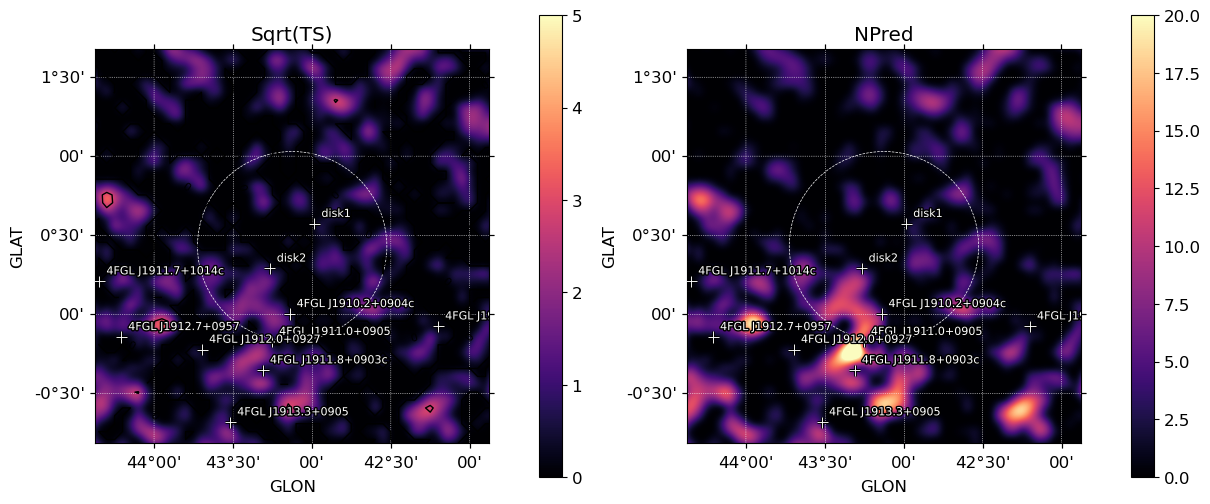

In [13]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_2disk',make_plots=True,write_fits=True,write_npy=True)
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 6)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=20,subplot=122,cmap='magma', zoom = 6)
plt.gca().set_title('NPred')
plt.show()

# Source localize

In [15]:
gta.delete_source('disk1')
gta.delete_source('disk2')
gta.print_model()

2025-05-01 13:04:07 INFO    GTAnalysis.delete_source(): Deleting source disk1
2025-05-01 13:04:07 INFO    GTAnalysis.delete_source(): Deleting source disk2
2025-05-01 13:04:07 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1910.2+0904c     0.430   0.331  3.61e-06   2.46     68.73        80.2    *
4FGL J1911.0+0905      0.619   0.722  2.75e-05   2.22   2041.23       664.8    *
4FGL J1911.8+0903c     0.808   0.225  9.84e-07   2.96      7.24        30.4    *
4FGL J1912.0+0927      0.869   1.083  4.01e-07   4.84      4.96        17.5    *
4FGL J1908.7+0812      1.056   0.692  6.25e-07   2.65      8.63        24.9    *
4FGL J1913.3+0905      1.183   2.796  1.11e-06   4.13     38.36        48.8    *
4FGL J1912.7+0957      1.226   0.032  5.87e-07  -0.28     10.32        24.2    *
4FGL J1911.7+1014c     1.241   2.213  1.45e-06   4.52     12

In [ ]:
plt.clf()
tsmap_no_source = gta.tsmap(prefix='TSmap_no_source',make_plots=True,write_fits=True,write_npy=True)

<Figure size 640x480 with 0 Axes>

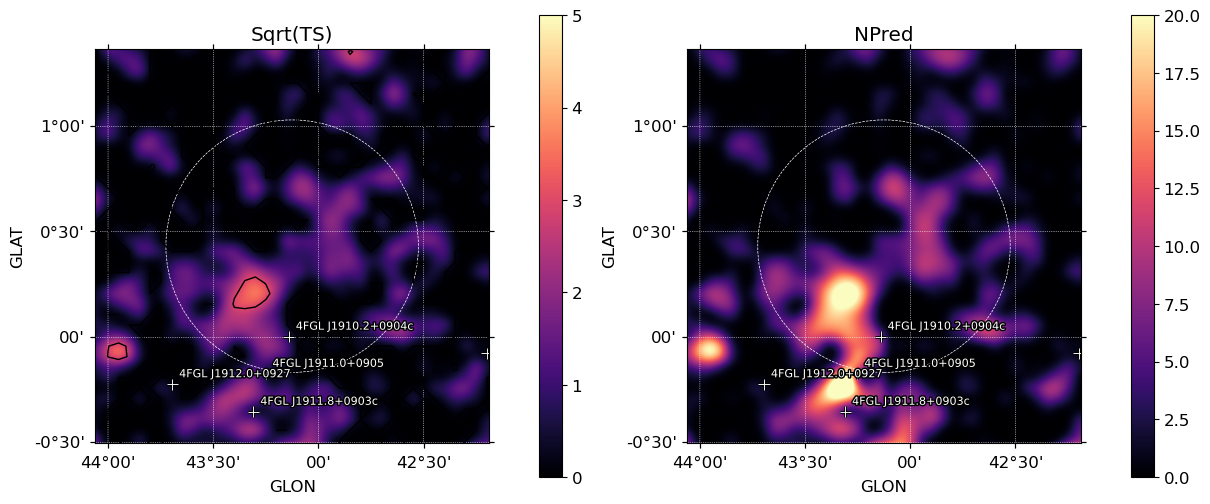

In [19]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_no_source['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_no_source['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=20,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

Text(0.5, 1.0, 'Excess Counts')

<Figure size 640x480 with 0 Axes>

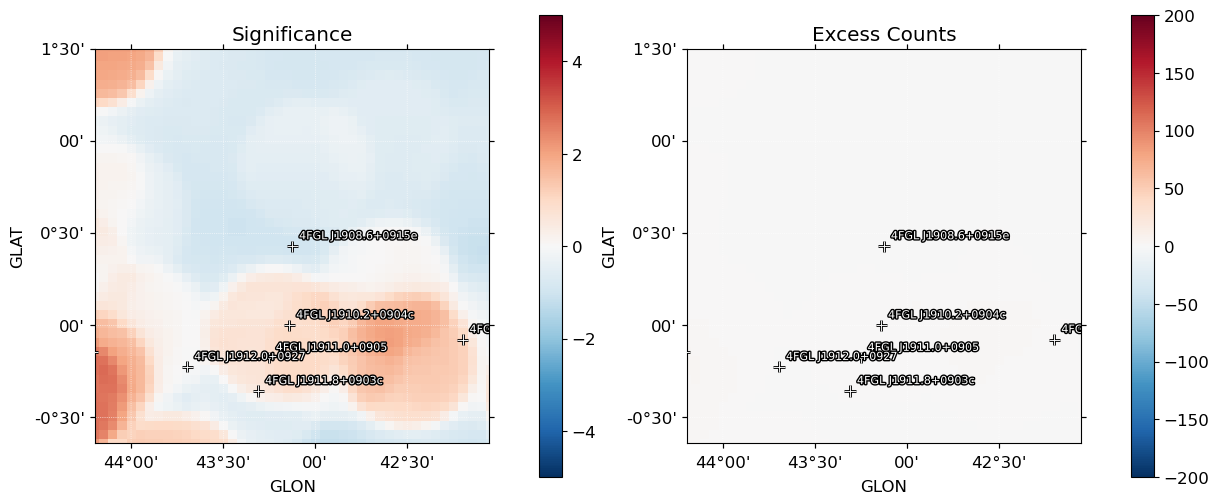

In [18]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid['sigma'],roi=gta.roi).plot(vmin=-5,vmax=5,levels=[-5,-3,3,5,7,9],subplot=121,cmap='RdBu_r', zoom = 7)
plt.gca().set_title('Significance')
ROIPlotter(resid['excess'],roi=gta.roi).plot(vmin=-200,vmax=200,subplot=122,cmap='RdBu_r', zoom = 7)
plt.gca().set_title('Excess Counts')

In [20]:
resid_noj0621 = gta.residmap('sgr1900_roi_fit_no4FGL',
                model=model,
                exclude=['4FGL J1908.6+0915e'])

2025-04-30 15:58:48 INFO    GTAnalysis.residmap(): Generating residual maps
2025-04-30 15:58:48 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2025-04-30 15:58:59 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2025-04-30 15:59:00 INFO    GTAnalysis.residmap(): Finished residual maps
2025-04-30 15:59:02 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/sgr1900_roi_fit_no4FGL_radialdisk_powerlaw_-2.24_residmap.npy
2025-04-30 15:59:02 INFO    GTAnalysis.residmap(): Execution time: 13.43 s


Text(0.5, 1.0, 'Excess Counts')

<Figure size 640x480 with 0 Axes>

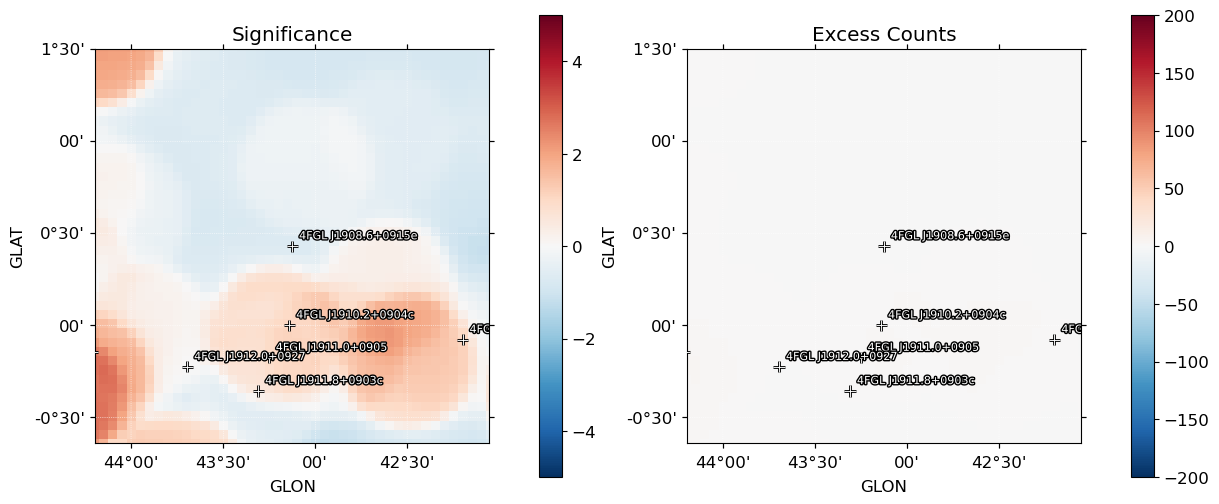

In [21]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid_noj0621['sigma'],roi=gta.roi).plot(vmin=-5,vmax=5,levels=[-5,-3,3,5,7,9],subplot=121,cmap='RdBu_r', zoom = 7)
plt.gca().set_title('Significance')
ROIPlotter(resid_noj0621['excess'],roi=gta.roi).plot(vmin=-200,vmax=200,subplot=122,cmap='RdBu_r', zoom = 7)
plt.gca().set_title('Excess Counts')

In [22]:
tsmap_noj0621 = gta.tsmap('sgr1900_noj0621',
                model=model,
                exclude=['4FGL J1908.6+0915e'])

2025-04-30 16:00:02 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-30 16:00:14 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-30 16:01:30 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-30 16:01:32 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/sgr1900_noj0621_radialdisk_powerlaw_-2.24_tsmap.npy
2025-04-30 16:01:32 INFO    GTAnalysis.tsmap(): Execution time: 89.41 s


<Figure size 640x480 with 0 Axes>

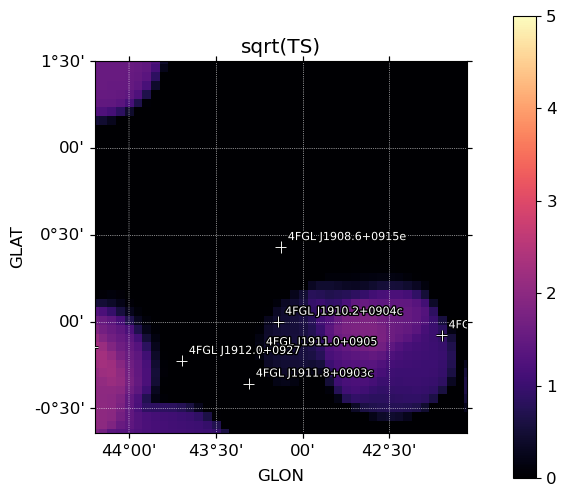

In [24]:
plt.clf()
fig = plt.figure(figsize=(6,6))
ROIPlotter(tsmap_noj0621['sqrt_ts'],roi=gta.roi).plot(vmin=0,vmax=5,levels=[3,5,7,9],subplot=111,cmap='magma', zoom = 7)
plt.gca().set_title('sqrt(TS)')
plt.show()

In [25]:
plt.clf()
tsmap_ = gta.tsmap(prefix='TSmap_sgr1900_all',make_plots=True,write_fits=True,write_npy=True)

2025-04-30 16:04:01 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-30 16:04:05 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-30 16:05:03 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-30 16:05:05 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_sgr1900_all_pointsource_powerlaw_2.00_tsmap.npy
2025-04-30 16:05:05 INFO    GTAnalysis.tsmap(): Execution time: 64.76 s


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

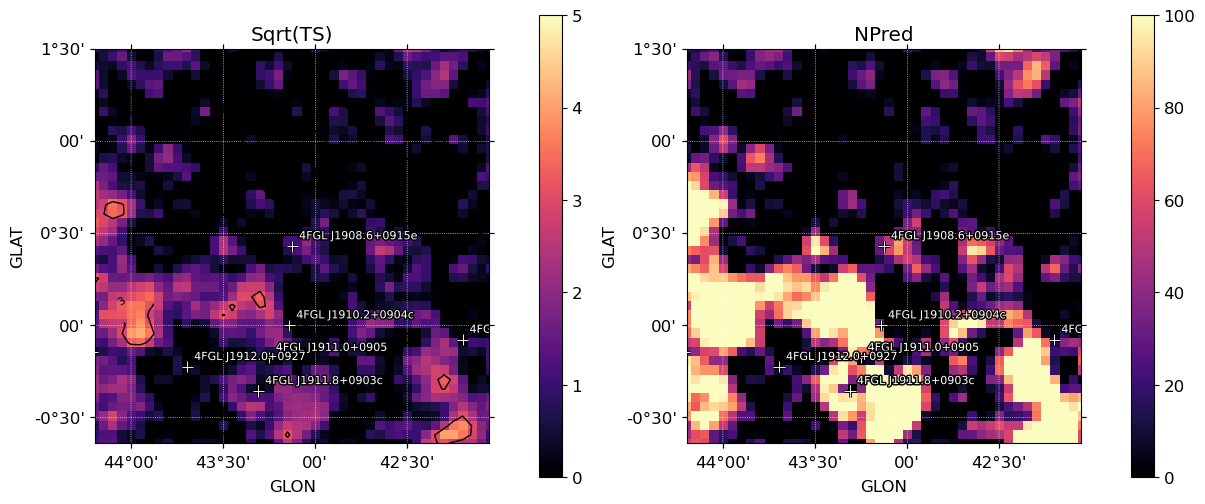

In [27]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 7)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma', zoom = 7)
plt.gca().set_title('NPred')
plt.show()

In [35]:
import numpy as np

# 1) Get your ROI center in Galactic coordinates
glon0, glat0 = gta.config['selection']['glon'], gta.config['selection']['glat']

# 2) Compute the two offsets (0.2° at 45°: upper‐right and lower‐left)
d = 0.2/np.sqrt(2)
pos = [
    (glon0 - d, glat0 + d),   # upper right
    (glon0 + d, glat0 - d)    # lower left
]

pos

[(42.98347864376269, 0.5715213562373095),
 (43.266321356237306, 0.2886786437626905)]

In [37]:
# Free only central objects
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[2.0],free=True)

# 3) (Optional) remove the original big disk
gta.delete_source('4FGL J1908.6+0915e')
gta.delete_source('disk1')
gta.delete_source('disk2')
# 4) Add your two small disks
for i, (gl, gb) in enumerate(pos, 1):
    gta.add_source(
        f'disk{i}',
        {
          'glon':         gl,
          'glat':         gb,
          'SpatialModel': 'RadialDisk',
          'Radius':       dict(value=0.2, scale=1.0, min=0.05, max=1.0),
          'SpectrumType': 'PowerLaw',
        },
        free=True,             # free all parameters of disk{i}
        init_source=True,      # do a quick local fit for each disk
        save_source_maps=True  # store their srcmaps for later
    )

# 5) Re‐optimize and fit the whole ROI



2025-04-30 16:15:09 ERROR   GTAnalysis.delete_source(): No source with name: 4FGL J1908.6+0915e
2025-04-30 16:15:09 INFO    GTAnalysis.delete_source(): Deleting source disk1
2025-04-30 16:15:10 INFO    GTAnalysis.delete_source(): Deleting source disk2
2025-04-30 16:15:10 INFO    GTAnalysis.add_source(): Adding source disk1
2025-04-30 16:15:20 INFO    GTAnalysis.add_source(): Adding source disk2


In [38]:
gta.print_model()

2025-04-30 16:15:28 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
disk1                  0.200   1.000  6.55e-06   2.00       nan       687.2    *
disk2                  0.200   1.000  6.55e-06   2.00       nan       684.3    *
4FGL J1910.2+0904c     0.430   0.452  1.11e-05   2.43    294.15      2321.2    *
4FGL J1911.0+0905      0.619   0.696  5.46e-05   2.19   6406.82     10452.2    *
4FGL J1911.8+0903c     0.808   0.529  5.62e-06   2.33     68.35      1031.5    *
4FGL J1912.0+0927      0.869   0.337  4.05e-06   2.76     89.59      1230.6    *
4FGL J1908.7+0812      1.056   1.750  6.74e-06   3.21    239.75      2368.4    *
4FGL J1913.3+0905      1.183   0.780   6.3e-06   3.28    320.68      1807.4    *
4FGL J1912.7+0957      1.226   0.488  4.86e-06   2.85    148.00      1512.6    *
4FGL J1911.7+1014c     1.241   0.340  3.33e-06   2.99 

In [39]:
gta.fit()

2025-04-30 16:15:36 INFO    GTAnalysis.fit(): Starting fit.
2025-04-30 16:16:44 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-04-30 16:16:44 INFO    GTAnalysis.fit(): LogLike:   222709.562 DeltaLogLike:       17.312 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 17.312421568436548,
 'edm': 0.0005992537107884161,
 'loglike': 222709.56158103538,
 'covariance': array([[ 1.13230042e-03, -8.32661972e-04,  2.03285650e-03, ...,
         -1.24379057e-06,  2.70882489e-06,  6.91941611e-05],
        [-8.32661972e-04,  2.26704536e-03, -1.07946297e-03, ...,
         -6.52662333e-06, -6.10783206e-06,  4.27033028e-06],
        [ 2.03285650e-03, -1.07946297e-03,  8.70471352e-03, ...,
          4.50723361e-06,  4.34223210e-06,  1.17462414e-05],
        ...,
        [-1.24379057e-06, -6.52662333e-06,  4.50723361e-06, ...,
          2.56550551e-06,  1.31722314e-06, -2.73531524e-05],
        [ 2.70882489e-06, -6.10783206e-06,  4.34223210e-06, ...,
          1.31722314e-06,  2.83913044e-06,  2.71781084e-05],
        [ 6.91941611e-05,  4.27033028e-06,  1.17462414e-05, ...,
         -2.73531524e-05,  2.71781084e-05,  2.02235848e-03]]),
 'correlation': array([[ 1.        , -0.51970607,  0.6475132

In [45]:
gta.print_model()

2025-04-30 16:21:37 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
disk1                  0.200   0.423  2.77e-06   2.00     13.12       290.4    *
disk2                  0.200   0.582  3.81e-06   2.00     19.80       398.0    *
4FGL J1910.2+0904c     0.430   0.441  1.09e-05   2.43    281.62      2266.6    *
4FGL J1911.0+0905      0.619   0.694  5.44e-05   2.19   6386.05     10424.0    *
4FGL J1911.8+0903c     0.808   0.530  5.65e-06   2.34     69.45      1045.5    *
4FGL J1912.0+0927      0.869   0.333     4e-06   2.76     87.46      1211.1    *
4FGL J1908.7+0812      1.056   1.754  6.75e-06   3.21    240.91      2374.0    *
4FGL J1913.3+0905      1.183   0.781   6.3e-06   3.28    321.02      1810.1    *
4FGL J1912.7+0957      1.226   0.488  4.86e-06   2.85    148.02      1513.3    *
4FGL J1911.7+1014c     1.241   0.339  3.32e-06   2.99 

In [41]:
plt.clf()
tsmap_2disk = gta.tsmap(prefix='TSmap_sgr1900_2disks',make_plots=True,write_fits=True,write_npy=True)

2025-04-30 16:16:44 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-30 16:16:48 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-30 16:17:45 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-30 16:17:47 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_sgr1900_2disks_pointsource_powerlaw_2.00_tsmap.npy
2025-04-30 16:17:47 INFO    GTAnalysis.tsmap(): Execution time: 62.68 s


<Figure size 640x480 with 0 Axes>

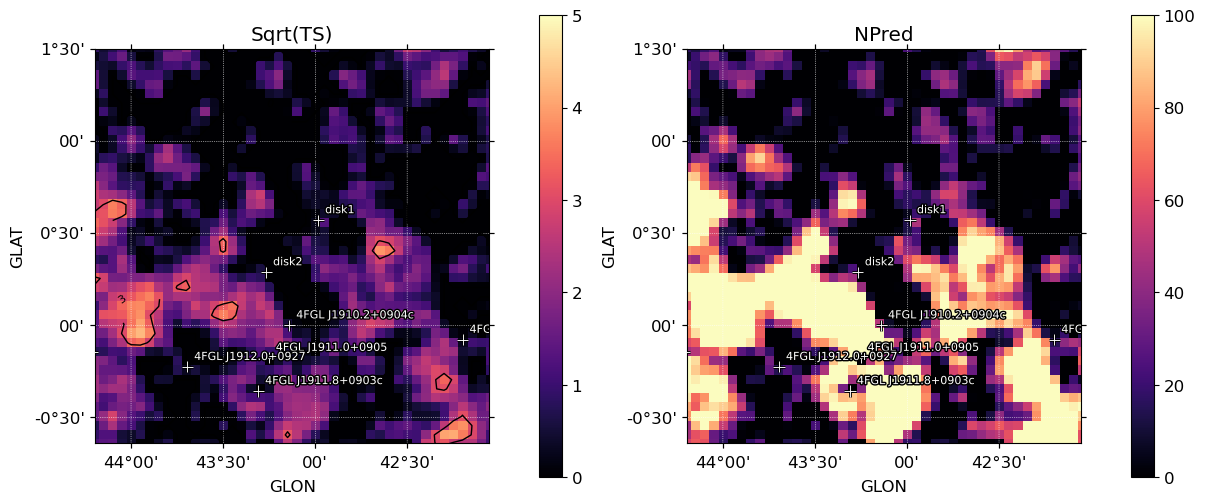

In [44]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_2disk['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 7)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_2disk['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma', zoom = 7)
plt.gca().set_title('NPred')
plt.show()

In [ ]:
from fermipy.gtanalysis import GTAnalysis
import numpy as np

# --- 0) assume gta already built and has your two 'disk1','disk2' sources ---
# --- 1) initial global fit to get things in the ballpark ---
gta.optimize()
gta.fit()

# --- 2) iterative loop: localize → refit → extension → refit ---
for iteration in range(2):
    print(f"\nIteration {iteration+1}: localize sources")
    for src in ['disk1','disk2']:
        loc = gta.localize(src, free_radius=0.3)  
        print(f"  {src}: RA={loc['ra']:.3f}  Dec={loc['dec']:.3f}")
    gta.optimize()
    gta.fit()

    print("   scan for extension")
    for src in ['disk1','disk2']:
        ext = gta.extension(src,
                            spatial_model='RadialDisk',
                            ext_radius=[0.05, 1.0],  # scan 0.05°–1.0°
                            free_radius=0.5)
        print(f"  {src}: best R = {ext['r68']:.3f}°  TS_ext = {ext['ts_ext']:.1f}")
    gta.optimize()
    gta.fit()

# --- 3) test alternative spectral models ---
for src in ['disk1','disk2']:
    print(f"\nTesting spectra for {src}")
    test = gta.spectral_analysis(src,
                                 models=['PowerLaw','LogParabola','PLSuperExpCutoff4'])
    print(test['summary'])
    # Suppose LogParabola wins for disk1, keep PL for disk2:
    best = test['best_model']
    gta.set_source_spectrum(src, best)

gta.optimize()
gta.fit()

# --- 4) final diagnostics ---
gta.print_model()
# residual TS‐map to check for leftovers
resid = gta.residmap('two_disk_resid',
                    model=[  # subtract both disks
                      {'SpatialModel':'RadialDisk','Radius': gta.roi['disk1'].spatial['r68'], 
                       'SpectrumType':gta.roi['disk1'].spectral['type'],
                       'Index':gta.roi['disk1'].spectral['pars']['Index']['value']},
                      {'SpatialModel':'RadialDisk','Radius': gta.roi['disk2'].spatial['r68'], 
                       'SpectrumType':gta.roi['disk2'].spectral['type'],
                       'Index':gta.roi['disk2'].spectral['pars']['Index']['value']}
                    ],
                    roiwidth=4.0, binsz=0.05)
gta.plot_residmap(resid)

2025-04-30 16:26:52 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602', '4FGL J1923.2+1408e', '4FGL J1911.0+0905', '4FGL J1857.7+0246e']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 3656011.612
Fitting shape 4FGL J1907.9+0602 TS:  26641.229
Fitting shape 4FGL J1923.2+1408e TS:  21701.787
Fitting shape 4FGL J1911.0+0905 TS:   6426.981
Fitting shape 4FGL J1846.3+0919 TS:   5516.681
Fitting shape 4FGL J1931.1+0937 TS:   3210.684
Fitting shape 4FGL J1942.7+1033 TS:   2867.341
Fitting shape 4FGL J1906.4+0723 TS:   1759.305
Fitting shape 4FGL J1857.7+0246e TS:   1085.464
Fitting shape 4FGL J1933.3+0726 TS:    951.515
Fitting shape 4FGL J1906.9+0712 TS:    758.991
Fitting shape 4FGL J1921.4+0136 TS:    484.215
Fitting shape 4FGL J1858.3+0209 TS:    452.688
Fitting shape 4FGL J1858.0+0354 TS:    399.480
Fitting shape 4FGL J1913.3+0905 TS:    324.275
Fitting shape 4FGL J1910.2+0904c TS:    286.485
Fitting shape 4FGL J1900.4+0339 TS:    269.762
Fitting shape 4FGL J1908.7+0812 TS:    247.382
Fitting shape 4FGL J1922.7+1428c TS:    208.799
Fitting shape 4FGL J1902.2+0448 TS:    196.419
Fitting shape 4FGL J1903.8+0531 TS:    181.724
Fitting shape 4FGL

2025-04-30 16:36:22 INFO    GTAnalysis.optimize(): Finished
2025-04-30 16:36:22 INFO    GTAnalysis.optimize(): LogLike: 222713.727628 Delta-LogLike: 4.166047
2025-04-30 16:36:22 INFO    GTAnalysis.optimize(): Execution time: 569.93 s
2025-04-30 16:36:22 INFO    GTAnalysis.fit(): Starting fit.
2025-04-30 16:37:30 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-04-30 16:37:30 INFO    GTAnalysis.fit(): LogLike:   222713.920 DeltaLogLike:        0.192 
2025-04-30 16:37:30 INFO    GTAnalysis.localize(): Running localization for disk1



Iteration 1: localize sources


2025-04-30 16:38:19 INFO    GTAnalysis._localize(): Localization succeeded.
2025-04-30 16:38:19 INFO    GTAnalysis._localize(): Updating source disk1 to localized position.
2025-04-30 16:38:19 INFO    GTAnalysis.delete_source(): Deleting source disk1
2025-04-30 16:38:19 INFO    GTAnalysis.add_source(): Adding source disk1
2025-04-30 16:38:33 INFO    GTAnalysis._localize(): Localization completed with new position:
(  ra, dec) = (  286.9684 +/-   0.1080,    9.1276 +/-   0.1512)
(glon,glat) = (   42.9204 +/-   0.1259,    0.5370 +/-   0.1368)
offset =   0.0719 r68 =   0.1877 r95 =   0.3028 r99 =   0.3755
2025-04-30 16:38:33 INFO    GTAnalysis._localize(): LogLike:   222715.958 DeltaLogLike:        2.038
2025-04-30 16:38:33 INFO    GTAnalysis.localize(): Finished localization.
2025-04-30 16:38:34 WARNING GTAnalysis.localize(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat

KeyError: 'dts'

In [52]:
plt.clf()
tsmap_2disk = gta.tsmap(prefix='TSmap_sgr1900_2disks',make_plots=True,write_fits=True,write_npy=True)

2025-04-30 16:41:47 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-30 16:41:51 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-30 16:42:49 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-30 16:42:52 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_sgr1900_2disks_pointsource_powerlaw_2.00_tsmap.npy
2025-04-30 16:42:52 INFO    GTAnalysis.tsmap(): Execution time: 64.63 s


<Figure size 640x480 with 0 Axes>

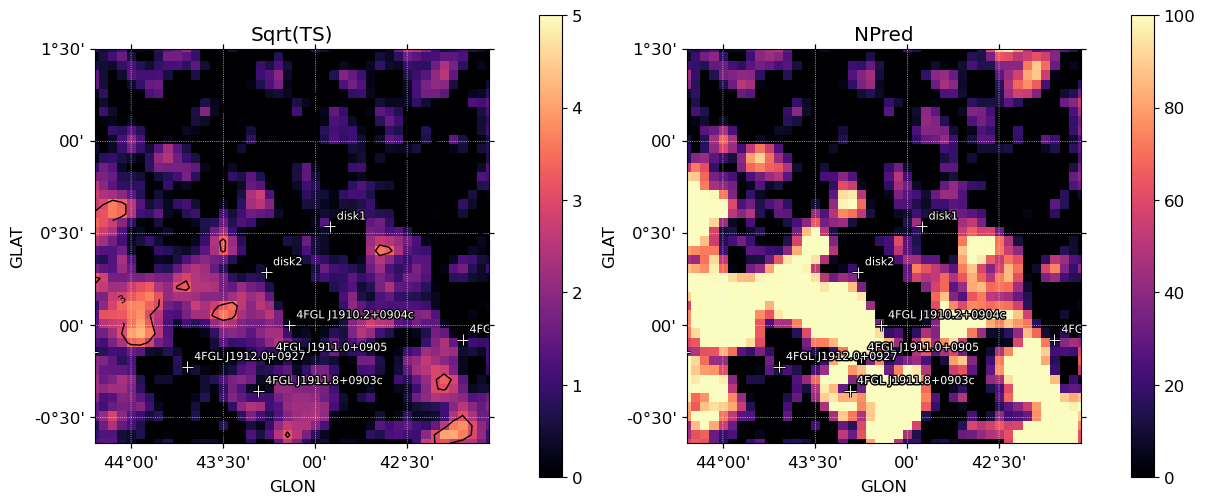

In [53]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_2disk['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 7)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_2disk['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma', zoom = 7)
plt.gca().set_title('NPred')
plt.show()

In [50]:
# subtract only the diffuse components
resid_bg = gta.residmap('data_minus_diffuse',
                       model=['galdiff','isodiff'],
                       roiwidth=4.0, binsz=0.05)
gta.plot_residmap(resid_bg, cb_label='Counts excess')

2025-04-30 16:40:46 INFO    GTAnalysis.residmap(): Generating residual maps


Exception: Conflicting types in dictionary merge for key model <class 'dict'> <class 'list'>